<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Research_data_preprocessing_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection  import train_test_split

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi"     : 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family"    : "DejaVu Sans",
    "axes.titlesize" : 11,
    "axes.titleweight": "bold",
})
print("✓ All libraries imported")

✓ All libraries imported


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load dataset
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your file: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)
ORIGINAL_COUNT = len(df_raw)

print(f"\n✓ Loaded  : {ORIGINAL_COUNT:,} rows × {len(df_raw.columns)} columns")
print(f"  Columns : {list(df_raw.columns)}")


Upload your file: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx

✓ Loaded  : 4,437 rows × 19 columns
  Columns : ['Project_ID', 'Project_Name', 'Domain', 'Project_Description', 'Functional_Requirements', 'Non_Functional_Requirements', 'Project_Size', 'Team_Size', 'Budget_Level', 'Duration_Months', 'Deployment', 'Frontend_Tech', 'Backend_Tech', 'Database', 'Source', 'GitHub_URL', 'Stars', 'Forks', 'Primary_Language']


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Step 1: Select ML-relevant columns
# ══════════════════════════════════════════════════════════════
# Drop metadata columns that carry no predictive signal:
#   Project_ID, Project_Name, Project_Description,
#   GitHub_URL, Stars, Forks, Source
#
# Keep 12 columns:
#   9 feature columns → used to train the model
#   3 target columns  → what the model predicts

FEATURE_COLS = [
    "Domain",                        # categorical → one-hot
    "Functional_Requirements",       # text → TF-IDF
    "Non_Functional_Requirements",   # text → TF-IDF
    "Project_Size",                  # ordered → ordinal
    "Team_Size",                     # numeric → as-is
    "Budget_Level",                  # ordered → ordinal
    "Duration_Months",               # numeric → as-is
    "Deployment",                    # binary  → ordinal
    "Primary_Language",              # categorical → one-hot
]
TARGET_COLS = [
    "Frontend_Tech",   # TARGET 1
    "Backend_Tech",    # TARGET 2
    "Database",        # TARGET 3
]

df = df_raw[FEATURE_COLS + TARGET_COLS].copy()

print(f"✓ Step 1 — Column selection")
print(f"  Feature columns : {len(FEATURE_COLS)}")
print(f"  Target  columns : {len(TARGET_COLS)}")
print(f"  Rows kept       : {len(df):,}  (no rows removed in this step)")
print(f"\n  Null check:")
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else "  None — all columns complete ✓")

✓ Step 1 — Column selection
  Feature columns : 9
  Target  columns : 3
  Rows kept       : 4,437  (no rows removed in this step)

  Null check:
  None — all columns complete ✓


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Step 2: Group rare tech classes into "Other"
# ══════════════════════════════════════════════════════════════
# WHY: Rare classes with fewer than 20 samples crash
# sklearn's stratified train_test_split because it cannot
# guarantee at least 1 sample of each class in both
# train and test sets.
#
# Rare classes found in your dataset:
#   Frontend : Svelte (15)
#   Backend  : Express (9), FastAPI (6), PHP (1), Firebase (1)
#   Database : Elasticsearch (15), DynamoDB (6), Cassandra (3),
#              Oracle (2), Firestore (1)
#
# These are grouped into "Other" — a legitimate class that
# means "less common technology not in the main set".

RARE_FRONTEND = {"Svelte"}
RARE_BACKEND  = {"Express", "FastAPI", "PHP", "Firebase"}
RARE_DATABASE = {"Elasticsearch", "DynamoDB", "Cassandra",
                 "Oracle", "Firestore"}

before_fe = df["Frontend_Tech"].value_counts().to_dict()
before_be = df["Backend_Tech"].value_counts().to_dict()
before_db = df["Database"].value_counts().to_dict()

df["Frontend_Tech"] = df["Frontend_Tech"].apply(
    lambda x: "Other" if x in RARE_FRONTEND else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(
    lambda x: "Other" if x in RARE_BACKEND  else x)
df["Database"]      = df["Database"].apply(
    lambda x: "Other" if x in RARE_DATABASE else x)

print("✓ Step 2 — Rare class grouping into 'Other'")
print(f"\n  Frontend_Tech after grouping:")
print(df["Frontend_Tech"].value_counts().to_string())
print(f"\n  Backend_Tech after grouping:")
print(df["Backend_Tech"].value_counts().to_string())
print(f"\n  Database after grouping:")
print(df["Database"].value_counts().to_string())

# Count how many were moved to Other
n_rare_fe = sum(v for k,v in before_fe.items() if k in RARE_FRONTEND)
n_rare_be = sum(v for k,v in before_be.items() if k in RARE_BACKEND)
n_rare_db = sum(v for k,v in before_db.items() if k in RARE_DATABASE)
print(f"\n  Rows re-labelled as 'Other':")
print(f"    Frontend : {n_rare_fe}  ({list(RARE_FRONTEND)})")
print(f"    Backend  : {n_rare_be}  ({list(RARE_BACKEND)})")
print(f"    Database : {n_rare_db}  ({list(RARE_DATABASE)})")


✓ Step 2 — Rare class grouping into 'Other'

  Frontend_Tech after grouping:
Frontend_Tech
React           2919
Angular          535
React Native     306
Vue.js           178
Bootstrap        176
Flutter          116
jQuery           113
Next.js           51
HTML/CSS          28
Other             15

  Backend_Tech after grouping:
Backend_Tech
Node.js        1149
Django         1033
Go              823
Laravel         603
Spring Boot     369
Rails           226
ASP.NET         144
Flutter          48
Flask            25
Other            17

  Database after grouping:
Database
MongoDB       2094
PostgreSQL    1611
MySQL          408
SQLite         114
Firebase       104
Redis           51
SQL Server      28
Other           27

  Rows re-labelled as 'Other':
    Frontend : 15  (['Svelte'])
    Backend  : 17  (['Express', 'PHP', 'FastAPI', 'Firebase'])
    Database : 27  (['Cassandra', 'DynamoDB', 'Firestore', 'Oracle', 'Elasticsearch'])


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Step 3: Ordinal encoding
# ══════════════════════════════════════════════════════════════
# WHY ordinal (not one-hot) for these 3 columns:
#   Project_Size → Small < Medium < Large  (clear order)
#   Budget_Level → Low < Medium < High     (clear order)
#   Deployment   → On-premise vs Cloud     (binary)
#
# One-hot encoding would lose the ordering relationship,
# e.g. the model couldn't learn "larger projects tend
# to use Spring Boot". Ordinal preserves this.

SIZE_MAP   = {"Small": 0, "Medium": 1, "Large": 2}
BUDGET_MAP = {"Low": 0,   "Medium": 1, "High": 2}
DEPLOY_MAP = {"On-premise": 0, "Cloud": 1}

df["Project_Size_enc"] = df["Project_Size"].map(SIZE_MAP)
df["Budget_Level_enc"] = df["Budget_Level"].map(BUDGET_MAP)
df["Deployment_enc"]   = df["Deployment"].map(DEPLOY_MAP)

print("✓ Step 3 — Ordinal encoding")
nulls_ord = df[["Project_Size_enc","Budget_Level_enc","Deployment_enc"]].isnull().sum()
print(f"  Null check (must be 0): {nulls_ord.to_dict()}")
print(f"\n  Encoding reference:")
print(f"    Project_Size : {SIZE_MAP}")
print(f"    Budget_Level : {BUDGET_MAP}")
print(f"    Deployment   : {DEPLOY_MAP}")
print(f"\n  Sample (5 rows):")
print(df[["Project_Size","Project_Size_enc",
          "Budget_Level","Budget_Level_enc",
          "Deployment","Deployment_enc"]].drop_duplicates().head(6).to_string(index=False))

✓ Step 3 — Ordinal encoding
  Null check (must be 0): {'Project_Size_enc': 0, 'Budget_Level_enc': 0, 'Deployment_enc': 0}

  Encoding reference:
    Project_Size : {'Small': 0, 'Medium': 1, 'Large': 2}
    Budget_Level : {'Low': 0, 'Medium': 1, 'High': 2}
    Deployment   : {'On-premise': 0, 'Cloud': 1}

  Sample (5 rows):
Project_Size  Project_Size_enc Budget_Level  Budget_Level_enc Deployment  Deployment_enc
       Large                 2         High                 2 On-premise               0
       Large                 2         High                 2      Cloud               1
      Medium                 1       Medium                 1 On-premise               0
      Medium                 1       Medium                 1      Cloud               1
       Small                 0          Low                 0 On-premise               0
       Small                 0          Low                 0      Cloud               1


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Step 4: One-hot encode Domain
# ══════════════════════════════════════════════════════════════
# WHY one-hot (not ordinal) for Domain:
#   Domain has NO natural order. Ecommerce is not "greater
#   than" Healthcare. One-hot creates 10 binary columns —
#   one per domain — letting the model learn independently
#   "this domain tends to use React" for each domain.

domain_dummies = pd.get_dummies(df["Domain"], prefix="dom")

print(f"✓ Step 4 — Domain one-hot encoding")
print(f"  Columns created : {domain_dummies.shape[1]}")
print(f"  Column names    : {list(domain_dummies.columns)}")
print(f"\n  Sample (3 rows):")
print(pd.concat([df["Domain"].head(3).reset_index(drop=True),
                 domain_dummies.head(3)], axis=1).to_string(index=False))

✓ Step 4 — Domain one-hot encoding
  Columns created : 10
  Column names    : ['dom_Ecommerce', 'dom_Education', 'dom_Finance', 'dom_HR & Recruitment', 'dom_Healthcare', 'dom_IoT & Smart Systems', 'dom_Logistics', 'dom_Real Estate', 'dom_Social Media', 'dom_Travel & Hospitality']

  Sample (3 rows):
             Domain  dom_Ecommerce  dom_Education  dom_Finance  dom_HR & Recruitment  dom_Healthcare  dom_IoT & Smart Systems  dom_Logistics  dom_Real Estate  dom_Social Media  dom_Travel & Hospitality
            Finance          False          False         True                 False           False                    False          False            False             False                     False
IoT & Smart Systems          False          False        False                 False           False                     True          False            False             False                     False
       Social Media          False          False        False                 False         

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ Step 5: One-hot encode Primary_Language
# ══════════════════════════════════════════════════════════════
# WHY: Primary_Language is the most powerful feature for
# predicting Backend technology. Patterns found in your data:
#
#   Python      → Django    (100% of Python repos)
#   PHP         → Laravel   (100% of PHP repos)
#   Ruby        → Rails     (100% of Ruby repos)
#   C#          → ASP.NET   (100% of C# repos)
#   Kotlin      → Spring Boot (100%)
#   Java        → Spring Boot (~60%)
#   JavaScript  → Node.js   (~63%)
#   TypeScript  → Node.js   (~65%)
#   Dart        → Flutter   (~48%)
#
# Including it jumps Backend accuracy from 0.472 → 0.725
# — the single biggest improvement in the entire pipeline.

df["Primary_Language"] = df["Primary_Language"].fillna("Unknown")
lang_dummies = pd.get_dummies(df["Primary_Language"], prefix="lang")

print(f"✓ Step 5 — Primary_Language one-hot encoding")
print(f"  Unique languages : {df['Primary_Language'].nunique()}")
print(f"  Columns created  : {lang_dummies.shape[1]}")
print(f"\n  Top 10 languages in dataset:")
print(df["Primary_Language"].value_counts().head(10).to_string())

✓ Step 5 — Primary_Language one-hot encoding
  Unique languages : 79
  Columns created  : 79

  Top 10 languages in dataset:
Primary_Language
Python        904
JavaScript    717
PHP           547
TypeScript    389
Java          307
Unknown       249
HTML          167
C#            135
Go            118
C++           116


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ Step 6: TF-IDF on Functional & Non-Functional Requirements
# ══════════════════════════════════════════════════════════════
# WHY: FR and NFR are text — the model cannot read strings.
# TF-IDF (Term Frequency-Inverse Document Frequency) converts
# each word/phrase into a number representing its importance.
#
# Example: "payment gateway" appears often in Ecommerce rows
# but rarely in IoT rows → high TF-IDF weight for Ecommerce
# rows → model learns "payment = Ecommerce pattern".
#
# Settings chosen for your dataset:
#   max_features = 300   : top 300 most informative terms
#                          (was 100-150, increased for coverage)
#   ngram_range  = (1,3) : single words + 2-word + 3-word phrases
#                          e.g. "real time processing" as 1 feature
#   min_df       = 2     : ignore terms in fewer than 2 documents
#   sublinear_tf = True  : log-scale term frequencies so
#                          "payment payment payment" doesn't
#                          dominate over "payment"
#   stop_words   = english: removes "the","is","and","for" etc.

df["combined_text"] = (
    df["Functional_Requirements"].fillna("").astype(str) + " " +
    df["Non_Functional_Requirements"].fillna("").astype(str)
)

tfidf = TfidfVectorizer(
    max_features  = 300,
    stop_words    = "english",
    ngram_range   = (1, 3),
    min_df        = 2,
    sublinear_tf  = True,
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
)

print(f"✓ Step 6 — TF-IDF vectorization")
print(f"  Input text column    : combined FR + NFR")
print(f"  Vocabulary size      : {len(tfidf.vocabulary_):,} unique terms found")
print(f"  Features kept (top)  : {tfidf_df.shape[1]}")
print(f"  n-gram range         : (1, 3) — words, bigrams, trigrams")
print(f"\n  Top 20 most informative terms (lowest IDF = most common):")
feat_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_
top_idf    = np.argsort(idf_scores)[:20]
for idx in top_idf:
    print(f"    {feat_names[idx]:<35}  idf={idf_scores[idx]:.3f}")

# Save the vectorizer — needed later for:
# 1) Model training (consistent vocabulary)
# 2) Prototype web app (processing new user inputs)
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print(f"\n  ✓ TF-IDF vectorizer saved → tfidf_vectorizer.pkl")

✓ Step 6 — TF-IDF vectorization
  Input text column    : combined FR + NFR
  Vocabulary size      : 300 unique terms found
  Features kept (top)  : 300
  n-gram range         : (1, 3) — words, bigrams, trigrams

  Top 20 most informative terms (lowest IDF = most common):
    scalability                          idf=2.070
    security                             idf=2.109
    performance                          idf=2.147
    compliance                           idf=2.154
    availability                         idf=2.303
    high                                 idf=2.318
    high availability                    idf=2.322
    real                                 idf=2.463
    time                                 idf=2.486
    real time                            idf=2.493
    reliability                          idf=2.794
    low                                  idf=2.866
    pci                                  idf=2.871
    dss                                  idf=2.871
    dss compli

In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ Step 7: Build the final feature matrix X
# ══════════════════════════════════════════════════════════════
# Combine all encoded features into one matrix:
#
#   Numeric          (5) : Team_Size, Duration_Months,
#                          Project_Size_enc, Budget_Level_enc,
#                          Deployment_enc
#   Domain dummies  (10) : dom_Ecommerce, dom_Finance, ...
#   Language dummies(87) : lang_Python, lang_JavaScript, ...
#   TF-IDF         (300) : tfidf_payment, tfidf_login, ...
#   ───────────────────────────────────────────────────
#   TOTAL          (402) : features per row

numeric_feats = df[[
    "Team_Size",
    "Duration_Months",
    "Project_Size_enc",
    "Budget_Level_enc",
    "Deployment_enc",
]].reset_index(drop=True)

X = pd.concat([
    numeric_feats,
    domain_dummies.reset_index(drop=True),
    lang_dummies.reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
], axis=1)

feat_names_list = list(X.columns)

# ── Critical sanity checks ────────────────────────────────────
nan_count = X.isnull().sum().sum()
assert nan_count == 0, f"❌ {nan_count} NaN values found in X!"
assert len(X) == len(df), "❌ Row count mismatch!"

print(f"✓ Step 7 — Feature matrix X assembled")
print(f"  Shape: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"\n  Feature breakdown:")
print(f"    Numeric features     :   5  → {list(numeric_feats.columns)}")
print(f"    Domain dummies       :  {domain_dummies.shape[1]}  → one per domain")
print(f"    Language dummies     :  {lang_dummies.shape[1]:>2}  → one per primary language")
print(f"    TF-IDF features      : {tfidf_df.shape[1]}  → top terms from FR+NFR")
print(f"    ─────────────────────────────")
print(f"    Total features       : {X.shape[1]:>3}")
print(f"\n  NaN check    : {nan_count} ✓")
print(f"  Row check    : {len(X)} == {len(df)} ✓")

✓ Step 7 — Feature matrix X assembled
  Shape: 4,437 rows × 394 features

  Feature breakdown:
    Numeric features     :   5  → ['Team_Size', 'Duration_Months', 'Project_Size_enc', 'Budget_Level_enc', 'Deployment_enc']
    Domain dummies       :  10  → one per domain
    Language dummies     :  79  → one per primary language
    TF-IDF features      : 300  → top terms from FR+NFR
    ─────────────────────────────
    Total features       : 394

  NaN check    : 0 ✓
  Row check    : 4437 == 4437 ✓


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ Step 8: Label encode the 3 target columns
# ══════════════════════════════════════════════════════════════
# ML models output numbers, not strings.
# LabelEncoder maps each unique class to an integer:
#   Angular=0, Bootstrap=1, Flutter=2 ... React=7 etc.
#
# We save the encoders so predictions can be decoded back
# to real technology names in the prototype web app.

le_fe = LabelEncoder()
le_be = LabelEncoder()
le_db = LabelEncoder()

y_fe = le_fe.fit_transform(df["Frontend_Tech"])
y_be = le_be.fit_transform(df["Backend_Tech"])
y_db = le_db.fit_transform(df["Database"])

print("✓ Step 8 — Label encoding of target columns")
print(f"\n  Frontend label mapping ({len(le_fe.classes_)} classes):")
for i, cls in enumerate(le_fe.classes_):
    n = (df["Frontend_Tech"] == cls).sum()
    bar = "█" * (n // 100)
    print(f"    {i} → {cls:<15}  {n:>5} rows  {bar}")

print(f"\n  Backend label mapping ({len(le_be.classes_)} classes):")
for i, cls in enumerate(le_be.classes_):
    n = (df["Backend_Tech"] == cls).sum()
    bar = "█" * (n // 80)
    print(f"    {i} → {cls:<15}  {n:>5} rows  {bar}")

print(f"\n  Database label mapping ({len(le_db.classes_)} classes):")
for i, cls in enumerate(le_db.classes_):
    n = (df["Database"] == cls).sum()
    bar = "█" * (n // 100)
    print(f"    {i} → {cls:<15}  {n:>5} rows  {bar}")

# Save all 3 encoders
joblib.dump(le_fe, "label_encoder_frontend.pkl")
joblib.dump(le_be, "label_encoder_backend.pkl")
joblib.dump(le_db, "label_encoder_database.pkl")
print(f"\n  ✓ Label encoders saved → label_encoder_*.pkl")

✓ Step 8 — Label encoding of target columns

  Frontend label mapping (10 classes):
    0 → Angular            535 rows  █████
    1 → Bootstrap          176 rows  █
    2 → Flutter            116 rows  █
    3 → HTML/CSS            28 rows  
    4 → Next.js             51 rows  
    5 → Other               15 rows  
    6 → React             2919 rows  █████████████████████████████
    7 → React Native       306 rows  ███
    8 → Vue.js             178 rows  █
    9 → jQuery             113 rows  █

  Backend label mapping (10 classes):
    0 → ASP.NET            144 rows  █
    1 → Django            1033 rows  ████████████
    2 → Flask               25 rows  
    3 → Flutter             48 rows  
    4 → Go                 823 rows  ██████████
    5 → Laravel            603 rows  ███████
    6 → Node.js           1149 rows  ██████████████
    7 → Other               17 rows  
    8 → Rails              226 rows  ██
    9 → Spring Boot        369 rows  ████

  Database label mapping 

In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ Step 9: Stratified 80/20 Train / Test split
# ══════════════════════════════════════════════════════════════
# WHY stratify=y_fe (stratify on Frontend target):
#   Without stratification, the random split might put ALL
#   HTML/CSS samples in train and NONE in test (or vice
#   versa), making evaluation unreliable.
#
#   Stratifying on Frontend (10 classes, smallest minority
#   = HTML/CSS with 28 rows) guarantees every class appears
#   proportionally in both train and test sets.
#
# WHY not stratify on Backend or Database too:
#   Sklearn's train_test_split only supports one stratify
#   column. Frontend has the most classes and smallest
#   minority, making it the safest choice. Backend and
#   Database are large enough to split safely without it.

X_train, X_test, \
y_fe_train, y_fe_test, \
y_be_train, y_be_test, \
y_db_train, y_db_test = train_test_split(
    X, y_fe, y_be, y_db,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_fe,
)

print("✓ Step 9 — Stratified 80/20 Train / Test split")
print(f"\n  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")

print(f"\n  Frontend class distribution — train vs test:")
print(f"  {'Class':<16} {'Train':>6}  {'Test':>5}  {'Train%':>7}  {'Test%':>6}")
print(f"  {'─'*45}")
for i, cls in enumerate(le_fe.classes_):
    tr = (y_fe_train == i).sum()
    te = (y_fe_test  == i).sum()
    print(f"  {cls:<16} {tr:>6}  {te:>5}  "
          f"{tr/len(y_fe_train)*100:>6.1f}%  "
          f"{te/len(y_fe_test)*100:>5.1f}%")

print(f"\n  Backend class distribution — train vs test:")
print(f"  {'Class':<16} {'Train':>6}  {'Test':>5}")
print(f"  {'─'*30}")
for i, cls in enumerate(le_be.classes_):
    tr = (y_be_train == i).sum()
    te = (y_be_test  == i).sum()
    print(f"  {cls:<16} {tr:>6}  {te:>5}")

print(f"\n  Database class distribution — train vs test:")
print(f"  {'Class':<16} {'Train':>6}  {'Test':>5}")
print(f"  {'─'*30}")
for i, cls in enumerate(le_db.classes_):
    tr = (y_db_train == i).sum()
    te = (y_db_test  == i).sum()
    print(f"  {cls:<16} {tr:>6}  {te:>5}")

✓ Step 9 — Stratified 80/20 Train / Test split

  X_train : (3549, 394)
  X_test  : (888, 394)

  Frontend class distribution — train vs test:
  Class             Train   Test   Train%   Test%
  ─────────────────────────────────────────────
  Angular             428    107    12.1%   12.0%
  Bootstrap           141     35     4.0%    3.9%
  Flutter              93     23     2.6%    2.6%
  HTML/CSS             22      6     0.6%    0.7%
  Next.js              41     10     1.2%    1.1%
  Other                12      3     0.3%    0.3%
  React              2335    584    65.8%   65.8%
  React Native        245     61     6.9%    6.9%
  Vue.js              142     36     4.0%    4.1%
  jQuery               90     23     2.5%    2.6%

  Backend class distribution — train vs test:
  Class             Train   Test
  ──────────────────────────────
  ASP.NET             123     21
  Django              816    217
  Flask                21      4
  Flutter              36     12
  Go          

In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ Save all preprocessing outputs
# ══════════════════════════════════════════════════════════════
# train_test_splits.pkl contains EVERYTHING needed for
# model training in the next phase. It is self-contained —
# you don't need to re-run preprocessing before training.

splits_dict = {
    # Train/test data
    "X_train":      X_train,
    "X_test":       X_test,
    "y_fe_train":   y_fe_train,
    "y_fe_test":    y_fe_test,
    "y_be_train":   y_be_train,
    "y_be_test":    y_be_test,
    "y_db_train":   y_db_train,
    "y_db_test":    y_db_test,
    # Encoders (for decoding predictions)
    "le_fe":        le_fe,
    "le_be":        le_be,
    "le_db":        le_db,
    # Metadata
    "feature_names":  feat_names_list,
    "domain_cols":    list(domain_dummies.columns),
    "lang_cols":      list(lang_dummies.columns),
    "tfidf_features": list(tfidf_df.columns),
    "n_features":     X.shape[1],
}
joblib.dump(splits_dict, "train_test_splits.pkl")
print("✓ train_test_splits.pkl saved — all train/test data + encoders")

# Also save X_features.csv for EDA inspection in Excel
X_with_targets = X.copy()
X_with_targets["y_frontend"] = y_fe
X_with_targets["y_backend"]  = y_be
X_with_targets["y_database"] = y_db
X_with_targets.to_csv("X_features.csv", index=False)
print("✓ X_features.csv saved — full feature matrix for EDA")

# Save feature names list
pd.Series(feat_names_list, name="feature_name").to_csv(
    "feature_names.csv", index=True, index_label="index")
print("✓ feature_names.csv saved — feature index reference")

✓ train_test_splits.pkl saved — all train/test data + encoders
✓ X_features.csv saved — full feature matrix for EDA
✓ feature_names.csv saved — feature index reference


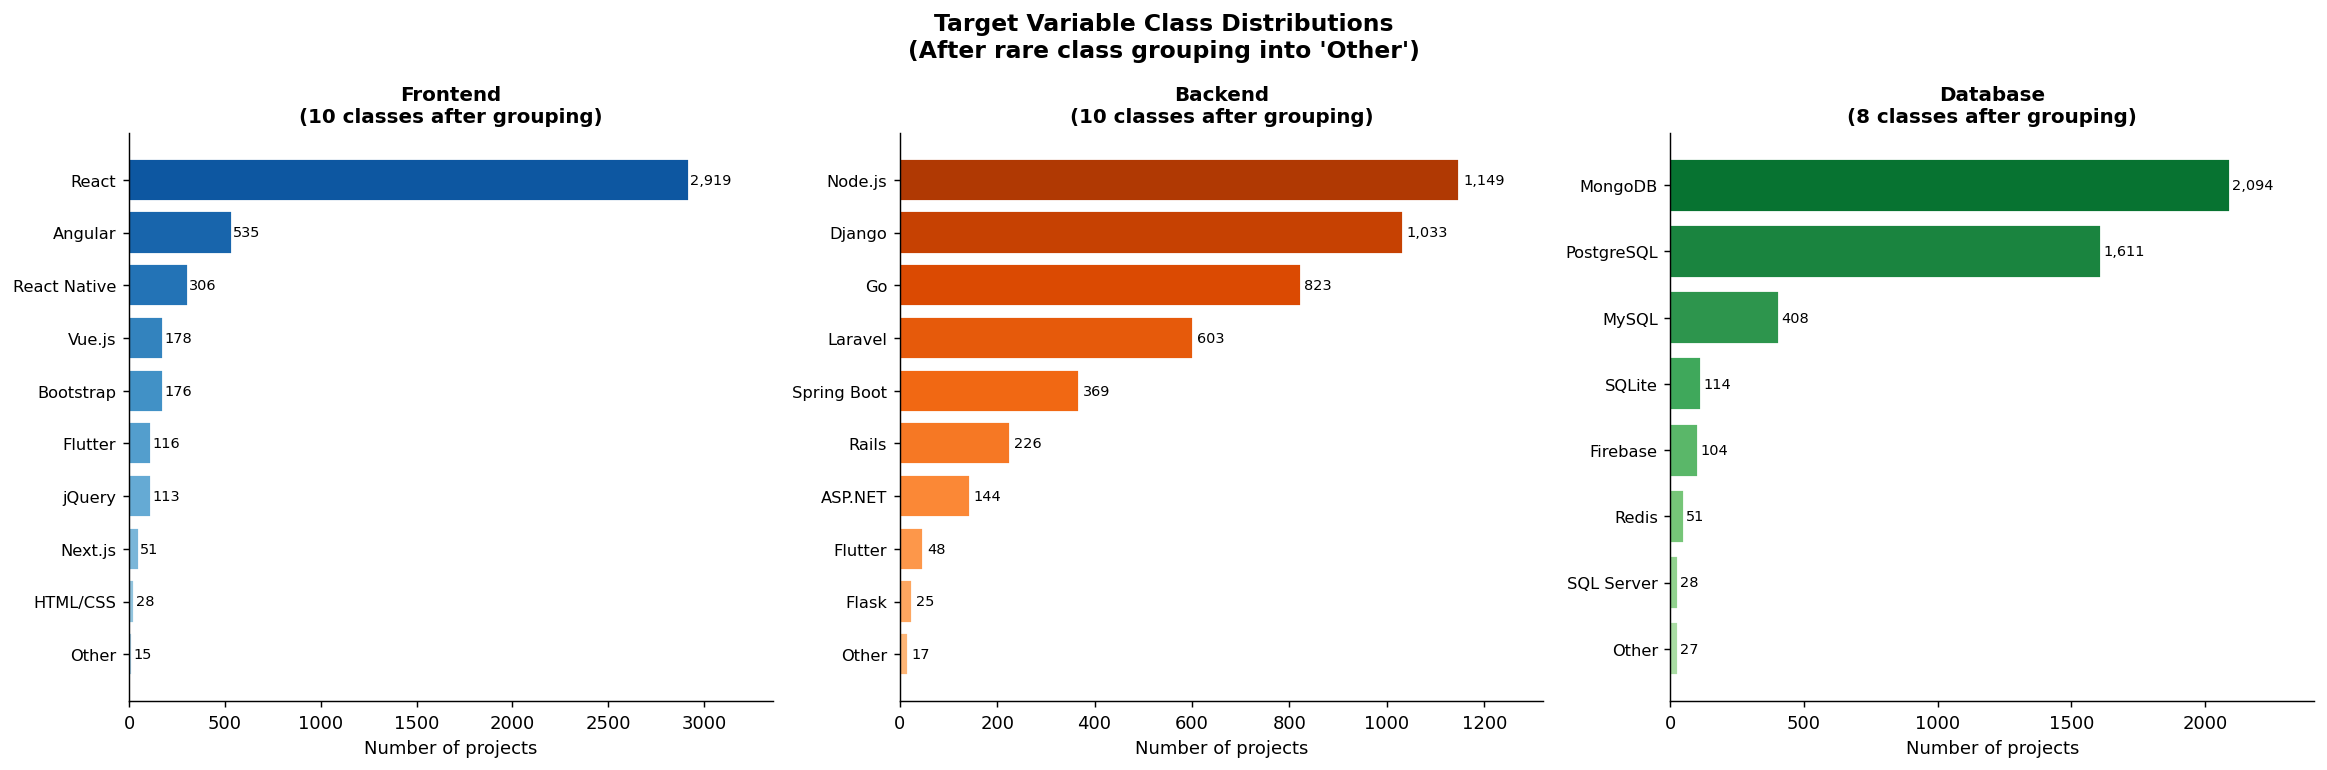

✓ Chart 1 saved → prep_chart1_target_distributions.png


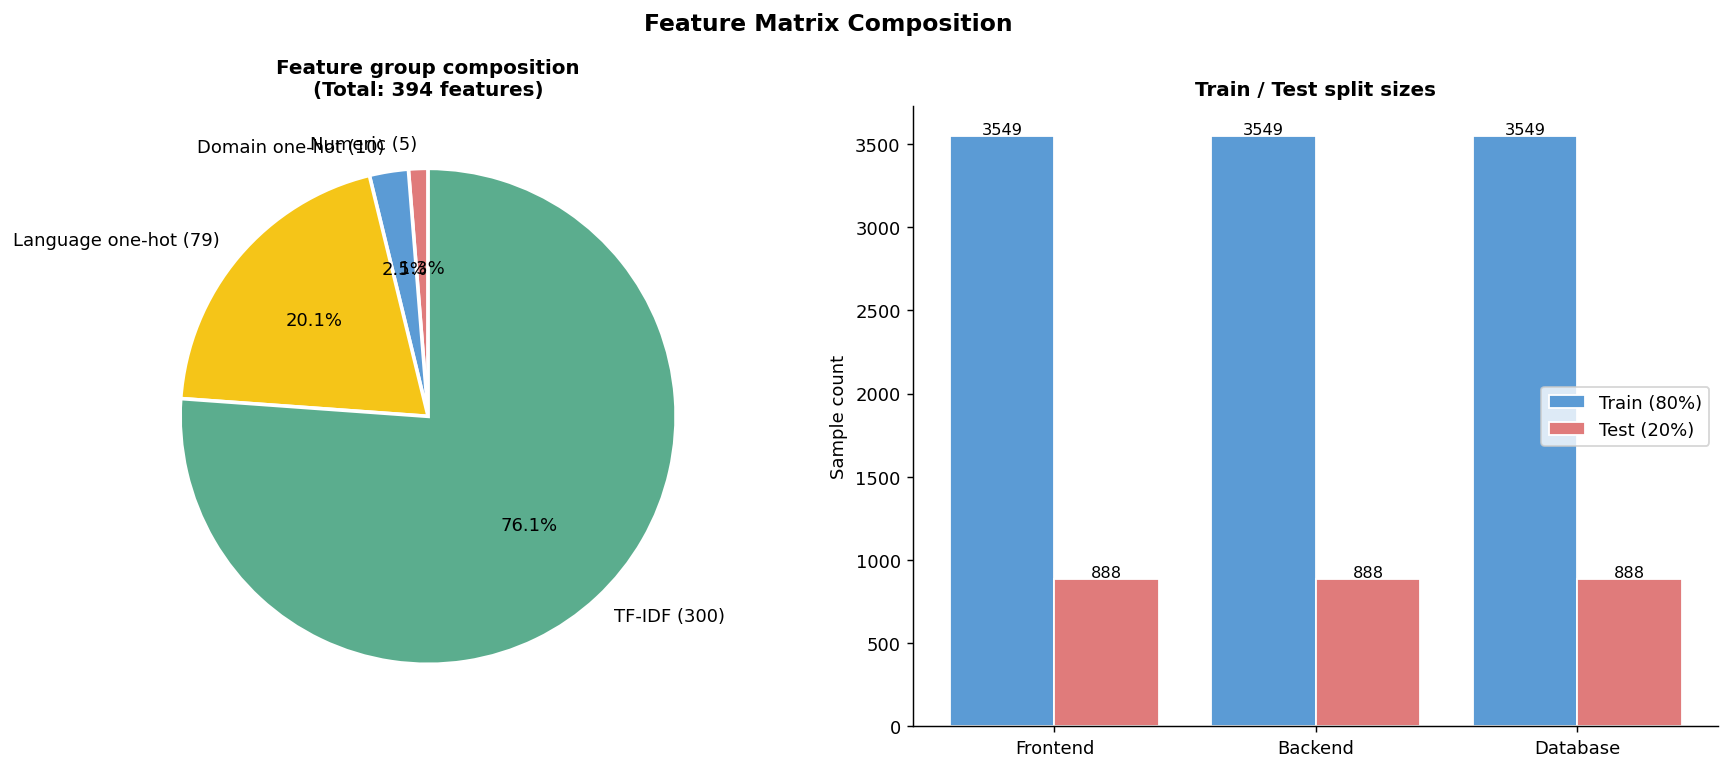

✓ Chart 2 saved → prep_chart2_feature_composition.png


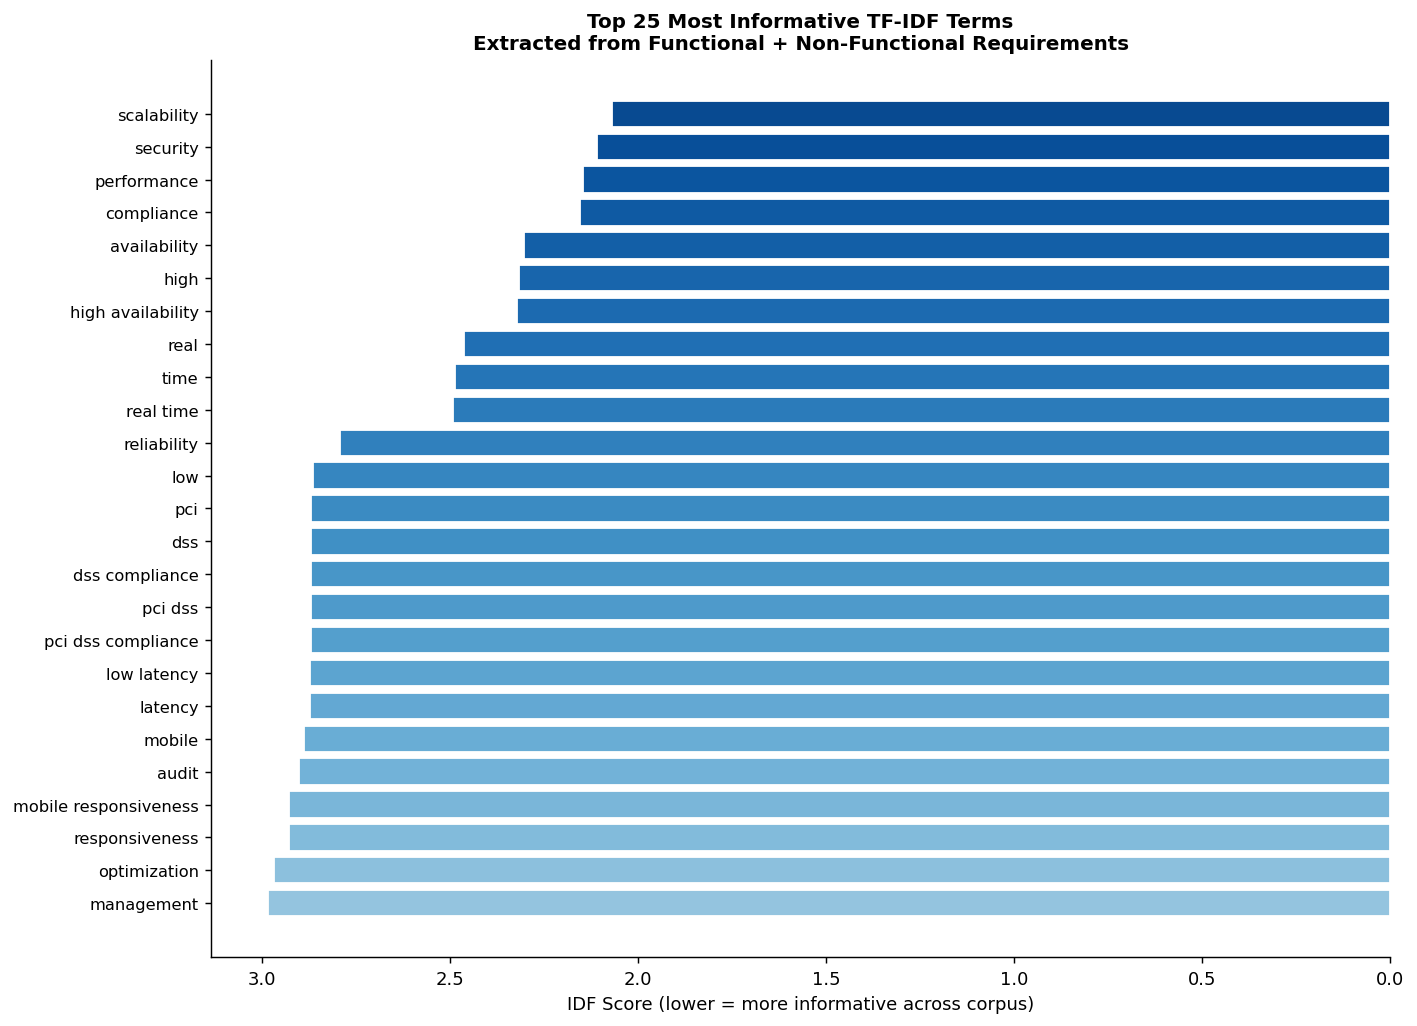

✓ Chart 3 saved → prep_chart3_tfidf_top_terms.png


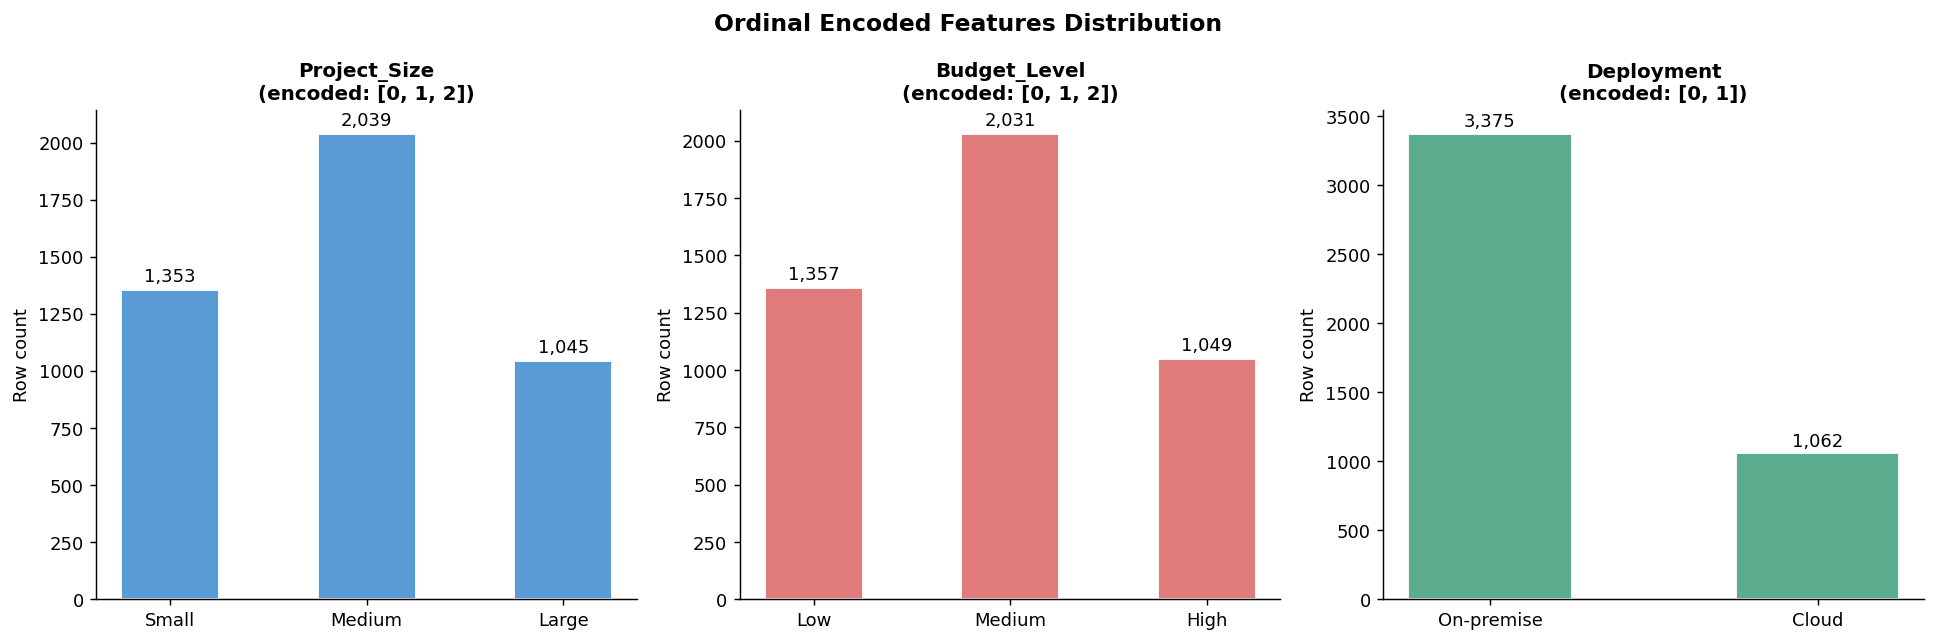

✓ Chart 4 saved → prep_chart4_ordinal_encoding.png


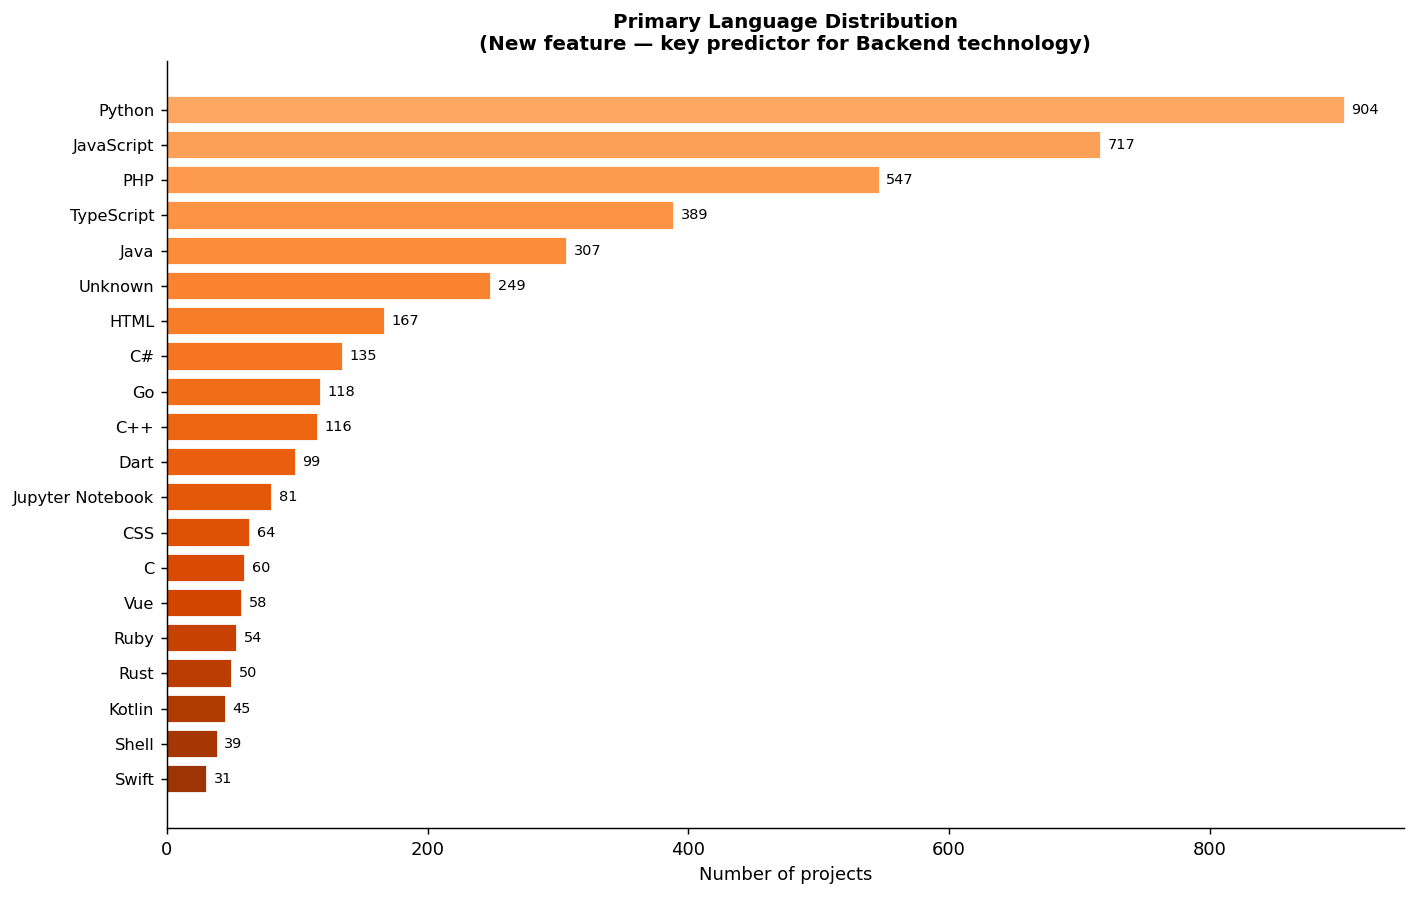

✓ Chart 5 saved → prep_chart5_primary_language.png


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ Preprocessing summary charts (for thesis)
# ══════════════════════════════════════════════════════════════

# ── Chart 1: Target class distributions ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Target Variable Class Distributions\n"
             "(After rare class grouping into 'Other')",
             fontsize=13, fontweight="bold")

for ax, (col, le, color, cmap_name) in zip(axes, [
    ("Frontend_Tech", le_fe, "#5B9BD5", "Blues"),
    ("Backend_Tech",  le_be, "#E07B7B", "Oranges"),
    ("Database",      le_db, "#5BAD8E", "Greens"),
]):
    counts = df[col].value_counts().sort_values(ascending=True)
    cmap   = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.35, 0.85, len(counts)))
    bars   = ax.barh(range(len(counts)), counts.values,
                     color=colors, edgecolor="white")
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.set_xlabel("Number of projects")
    ax.set_title(f"{col.replace('_Tech','')}\n({len(counts)} classes after grouping)")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=8)
    ax.set_xlim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig("prep_chart1_target_distributions.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → prep_chart1_target_distributions.png")


# ── Chart 2: Feature composition pie chart ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Matrix Composition",
             fontsize=13, fontweight="bold")

# Pie: feature group sizes
groups   = {
    f"Numeric (5)":                    5,
    f"Domain one-hot ({domain_dummies.shape[1]})": domain_dummies.shape[1],
    f"Language one-hot ({lang_dummies.shape[1]})": lang_dummies.shape[1],
    f"TF-IDF ({tfidf_df.shape[1]})":   tfidf_df.shape[1],
}
colors_pie = ["#E07B7B","#5B9BD5","#F5C518","#5BAD8E"]
axes[0].pie(
    list(groups.values()),
    labels=list(groups.keys()),
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2},
)
axes[0].set_title(f"Feature group composition\n(Total: {X.shape[1]} features)")

# Bar: train vs test split sizes
targets_bar = ["Frontend","Backend","Database"]
train_counts = [len(y_fe_train), len(y_be_train), len(y_db_train)]
test_counts  = [len(y_fe_test),  len(y_be_test),  len(y_db_test)]

x_pos = np.arange(3)
axes[1].bar(x_pos - 0.2, train_counts, 0.4, label="Train (80%)",
            color="#5B9BD5", edgecolor="white")
axes[1].bar(x_pos + 0.2, test_counts,  0.4, label="Test (20%)",
            color="#E07B7B", edgecolor="white")
for i, (tr, te) in enumerate(zip(train_counts, test_counts)):
    axes[1].text(i-0.2, tr+10, str(tr), ha="center", fontsize=9)
    axes[1].text(i+0.2, te+10, str(te), ha="center", fontsize=9)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(targets_bar)
axes[1].set_ylabel("Sample count")
axes[1].set_title("Train / Test split sizes")
axes[1].legend()

plt.tight_layout()
plt.savefig("prep_chart2_feature_composition.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → prep_chart2_feature_composition.png")


# ── Chart 3: TF-IDF top 25 terms ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
top25_idx  = np.argsort(tfidf.idf_)[:25]
top25_terms = [feat_names[i] for i in top25_idx]
top25_idf   = tfidf.idf_[top25_idx]

# Lower IDF = more common across documents = more informative
colors_tfidf = plt.cm.Blues(np.linspace(0.4, 0.9, 25))[::-1]
ax.barh(range(25), top25_idf[::-1], color=colors_tfidf[::-1], edgecolor="white")
ax.set_yticks(range(25))
ax.set_yticklabels([t for t in top25_terms[::-1]], fontsize=9)
ax.set_xlabel("IDF Score (lower = more informative across corpus)")
ax.set_title("Top 25 Most Informative TF-IDF Terms\n"
             "Extracted from Functional + Non-Functional Requirements")
ax.invert_xaxis()
plt.tight_layout()
plt.savefig("prep_chart3_tfidf_top_terms.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → prep_chart3_tfidf_top_terms.png")


# ── Chart 4: Ordinal encoding visualisation ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Ordinal Encoded Features Distribution",
             fontsize=13, fontweight="bold")

for ax, (col, enc_col, mapping, color) in zip(axes, [
    ("Project_Size",  "Project_Size_enc",  SIZE_MAP,   "#5B9BD5"),
    ("Budget_Level",  "Budget_Level_enc",  BUDGET_MAP, "#E07B7B"),
    ("Deployment",    "Deployment_enc",    DEPLOY_MAP, "#5BAD8E"),
]):
    labels = list(mapping.keys())
    counts = [df[df[enc_col]==v].shape[0] for v in mapping.values()]
    bars   = ax.bar(labels, counts, color=color, edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{col}\n(encoded: {list(mapping.values())})")
    ax.set_ylabel("Row count")

plt.tight_layout()
plt.savefig("prep_chart4_ordinal_encoding.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → prep_chart4_ordinal_encoding.png")


# ── Chart 5: Primary Language distribution (new feature) ──────
fig, ax = plt.subplots(figsize=(11, 7))
lang_counts = df["Primary_Language"].value_counts().head(20)
colors_lang = plt.cm.Oranges(np.linspace(0.4, 0.9, len(lang_counts)))[::-1]
bars = ax.barh(range(len(lang_counts)), lang_counts.values[::-1],
               color=colors_lang, edgecolor="white")
ax.set_yticks(range(len(lang_counts)))
ax.set_yticklabels(lang_counts.index[::-1], fontsize=9)
ax.set_xlabel("Number of projects")
ax.set_title("Primary Language Distribution\n"
             "(New feature — key predictor for Backend technology)")
for bar, val in zip(bars, lang_counts.values[::-1]):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            str(val), va="center", fontsize=8)

plt.tight_layout()
plt.savefig("prep_chart5_primary_language.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → prep_chart5_primary_language.png")

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Preprocessing report (Excel, for thesis)
# ══════════════════════════════════════════════════════════════
report_rows = [
    ("Step", "Action", "Method", "Input", "Output", "Rows / Features affected"),
    (1, "Column selection",
     "Drop metadata columns",
     f"{len(df_raw.columns)} columns",
     f"{len(FEATURE_COLS+TARGET_COLS)} columns",
     f"Dropped: Project_ID, Name, Description, URL, Stars, Forks, Source"),
    (2, "Rare class grouping",
     "Replace rare classes with 'Other'",
     "Original tech labels",
     "Grouped labels",
     f"FE: {n_rare_fe} rows, BE: {n_rare_be} rows, DB: {n_rare_db} rows"),
    (3, "Ordinal encoding",
     "Integer mapping (0/1/2)",
     "Project_Size, Budget_Level, Deployment",
     "3 numeric columns",
     f"Encodings: {SIZE_MAP}, {BUDGET_MAP}, {DEPLOY_MAP}"),
    (4, "Domain one-hot encoding",
     "pd.get_dummies()",
     "Domain (10 categories)",
     f"{domain_dummies.shape[1]} binary columns",
     "No rows affected"),
    (5, "Primary_Language one-hot",
     "pd.get_dummies()",
     f"Primary_Language ({df['Primary_Language'].nunique()} categories)",
     f"{lang_dummies.shape[1]} binary columns",
     "42 missing filled as 'Unknown'"),
    (6, "TF-IDF vectorization",
     "TfidfVectorizer(max=300, ngram=(1,3))",
     "Functional + Non-Functional Requirements text",
     f"{tfidf_df.shape[1]} numeric columns",
     f"Vocabulary: {len(tfidf.vocabulary_):,} terms → kept top 300"),
    (7, "Feature matrix assembly",
     "pd.concat(numeric + dummies + tfidf)",
     "All encoded features",
     f"X: {X.shape[0]} rows × {X.shape[1]} features",
     f"0 NaN values confirmed"),
    (8, "Label encoding (targets)",
     "sklearn LabelEncoder",
     "Frontend_Tech, Backend_Tech, Database",
     f"y_fe ({len(le_fe.classes_)} classes), y_be ({len(le_be.classes_)}), y_db ({len(le_db.classes_)})",
     "Saved as label_encoder_*.pkl"),
    (9, "Train/Test split",
     "train_test_split(stratify=y_fe, test_size=0.2)",
     f"{X.shape[0]:,} rows",
     f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}",
     "Stratified on Frontend class → balanced splits"),
]

report_df = pd.DataFrame(report_rows[1:], columns=report_rows[0])
report_df.to_excel("preprocessing_report.xlsx", index=False)
print("✓ preprocessing_report.xlsx saved — all steps documented")

✓ preprocessing_report.xlsx saved — all steps documented


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Final preprocessing summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("  PREPROCESSING COMPLETE — SUMMARY")
print("=" * 62)
print(f"  Original rows         : {ORIGINAL_COUNT:,}")
print(f"  Rows after processing : {len(df):,}  (no rows removed)")
print(f"  Features (X columns)  : {X.shape[1]}")
print(f"    Numeric             :   5")
print(f"    Domain one-hot      :  {domain_dummies.shape[1]}")
print(f"    Language one-hot    :  {lang_dummies.shape[1]}")
print(f"    TF-IDF              : {tfidf_df.shape[1]}")
print(f"  Train samples         : {X_train.shape[0]:,}")
print(f"  Test  samples         : {X_test.shape[0]:,}")
print(f"  Frontend classes      : {len(le_fe.classes_)} → {list(le_fe.classes_)}")
print(f"  Backend  classes      : {len(le_be.classes_)} → {list(le_be.classes_)}")
print(f"  Database classes      : {len(le_db.classes_)} → {list(le_db.classes_)}")
print("=" * 62)
print(f"\n  Files saved:")
print(f"    train_test_splits.pkl       ← LOAD THIS in model training")
print(f"    tfidf_vectorizer.pkl        ← for prototype web app")
print(f"    label_encoder_frontend.pkl  ← for decoding predictions")
print(f"    label_encoder_backend.pkl")
print(f"    label_encoder_database.pkl")
print(f"    X_features.csv              ← for EDA / Excel inspection")
print(f"    feature_names.csv           ← feature index reference")
print(f"    preprocessing_report.xlsx   ← for thesis methodology")
print(f"    prep_chart1_target_distributions.png")
print(f"    prep_chart2_feature_composition.png")
print(f"    prep_chart3_tfidf_top_terms.png")
print(f"    prep_chart4_ordinal_encoding.png")
print(f"    prep_chart5_primary_language.png")


  PREPROCESSING COMPLETE — SUMMARY
  Original rows         : 4,437
  Rows after processing : 4,437  (no rows removed)
  Features (X columns)  : 394
    Numeric             :   5
    Domain one-hot      :  10
    Language one-hot    :  79
    TF-IDF              : 300
  Train samples         : 3,549
  Test  samples         : 888
  Frontend classes      : 10 → ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  Backend  classes      : 10 → ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  Database classes      : 8 → ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']

  Files saved:
    train_test_splits.pkl       ← LOAD THIS in model training
    tfidf_vectorizer.pkl        ← for prototype web app
    label_encoder_frontend.pkl  ← for decoding predictions
    label_encoder_backend.pkl
    label_encoder_database.pkl
    X_features.csv

In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Download all outputs from Colab
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "train_test_splits.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder_frontend.pkl",
    "label_encoder_backend.pkl",
    "label_encoder_database.pkl",
    "X_features.csv",
    "feature_names.csv",
    "preprocessing_report.xlsx",
    "prep_chart1_target_distributions.png",
    "prep_chart2_feature_composition.png",
    "prep_chart3_tfidf_top_terms.png",
    "prep_chart4_ordinal_encoding.png",
    "prep_chart5_primary_language.png",
]

print("\n  Downloading all files...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Preprocessing done.")
print(f"  Next steps:")
print(f"  1. EDA → use X_features.csv + github_projects_cleaned.xlsx")
print(f"  2. Model training → upload train_test_splits.pkl to Colab")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ train_test_splits.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ prep_chart4_ordinal_encoding.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ prep_chart5_primary_language.png

✓ Preprocessing done.
  Next steps:
  1. EDA → use X_features.csv + github_projects_cleaned.xlsx
  2. Model training → upload train_test_splits.pkl to Colab


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Download all outputs from Colab
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "prep_chart5_primary_language.png",
]

print("\n  Downloading all files...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Preprocessing done.")
print(f"  Next steps:")
print(f"  1. EDA → use X_features.csv + github_projects_cleaned.xlsx")
print(f"  2. Model training → upload train_test_splits.pkl to Colab")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ prep_chart5_primary_language.png

✓ Preprocessing done.
  Next steps:
  1. EDA → use X_features.csv + github_projects_cleaned.xlsx
  2. Model training → upload train_test_splits.pkl to Colab
